Enhancement successful. Steps applied: ['Sharpening', 'Gaussian blur (3, 3)', 'CLAHE equalization']
Enhanced image saved to: C:\Users\ASUS\OneDrive\Desktop\image processing project\travers_cracking_enhnaced\enhanced\enhanced_transverse_120.jpg


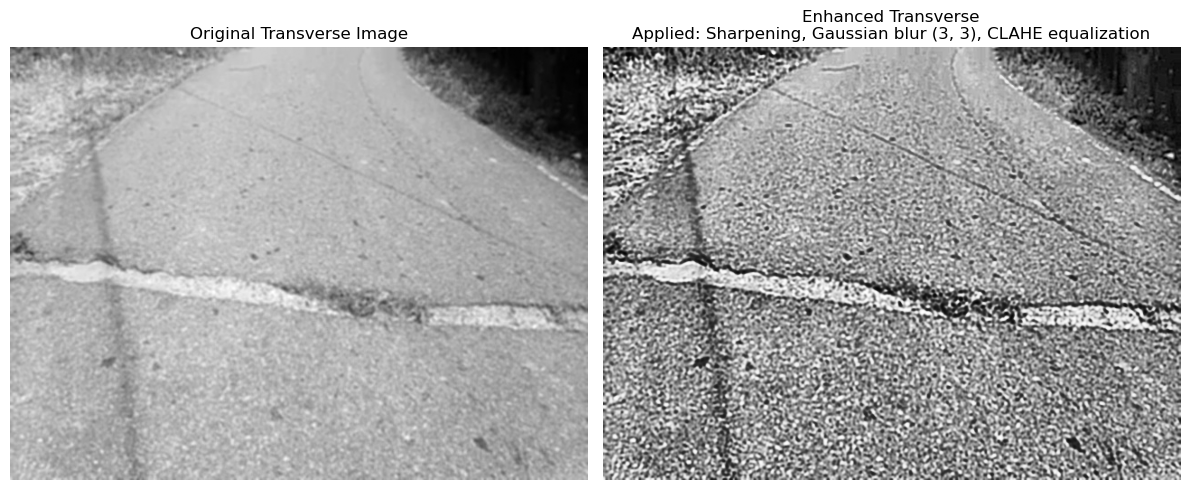

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def estimate_blur(image, threshold=200):
    laplacian = cv2.Laplacian(image, cv2.CV_64F)
    variance = laplacian.var()
    return variance, variance < threshold

def estimate_noise(image):
    blurred = cv2.GaussianBlur(image, (5, 5), 1.5)
    diff = cv2.absdiff(image, blurred)
    noise_level = np.mean(diff)
    return noise_level, noise_level > 10

def estimate_contrast(image):
    std_dev = np.std(image)
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    non_zero = np.where(hist > 0)[0]
    spread = non_zero[-1] - non_zero[0] if len(non_zero) > 0 else 0
    low_contrast = (std_dev < 40) or (spread < 150)
    return std_dev, spread, low_contrast

def dynamic_preprocess(image):
    steps_applied = []
    processed = image.copy()
    blur_value, is_blurry = estimate_blur(image)
    if is_blurry:
        kernel = np.array([[-1,-1,-1], [-1, 9,-1], [-1,-1,-1]])
        processed = cv2.filter2D(processed, -1, kernel)
        steps_applied.append("Sharpening")
    noise_level, is_noisy = estimate_noise(processed)
    if is_noisy:
        kernel_size = (7,7) if noise_level > 20 else (5,5) if noise_level > 15 else (3,3)
        processed = cv2.GaussianBlur(processed, kernel_size, 1.0)
        steps_applied.append(f"Gaussian blur {kernel_size}")
    std_dev, spread, low_contrast = estimate_contrast(processed)
    if low_contrast:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        processed = clahe.apply(processed)
        steps_applied.append("CLAHE equalization")
    return processed, steps_applied

file_path = r"C:\Users\ASUS\OneDrive\Desktop\image processing project\travers_cracking_enhnaced\enhanced_120.jpg"
output_folder = r"C:\Users\ASUS\OneDrive\Desktop\image processing project\travers_cracking_enhnaced\enhanced"

img = cv2.imread(file_path, 0)

if img is None:
    print(f"Error: Could not find image at {file_path}")
else:
    enhanced_img, steps = dynamic_preprocess(img)
    print(f"Enhancement successful. Steps applied: {steps}")

    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        print(f"Created directory: {output_folder}")

    output_path = os.path.join(output_folder, "enhanced_transverse_120.jpg")
    cv2.imwrite(output_path, enhanced_img)
    print(f"Enhanced image saved to: {output_path}")

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title("Original Transverse Image")
    plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(enhanced_img, cmap='gray'); plt.title(f"Enhanced Transverse\nApplied: {', '.join(steps)}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

Enhancement successful. Steps applied: ['Gaussian blur (3, 3)', 'CLAHE equalization']
Enhanced image saved to: C:\Users\ASUS\OneDrive\Desktop\image processing project\transverse_cracking_enhnaced\enhanced\enhanced_transverse_120.jpg


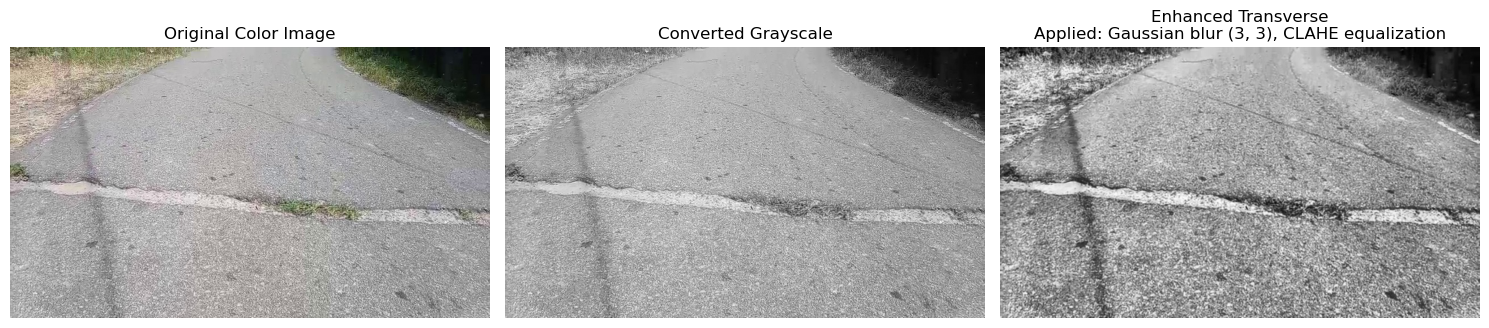

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def estimate_blur(image, threshold=200):
    laplacian = cv2.Laplacian(image, cv2.CV_64F)
    variance = laplacian.var()
    return variance, variance < threshold

def estimate_noise(image):
    blurred = cv2.GaussianBlur(image, (5, 5), 1.5)
    diff = cv2.absdiff(image, blurred)
    noise_level = np.mean(diff)
    return noise_level, noise_level > 10

def estimate_contrast(image):
    std_dev = np.std(image)
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    non_zero = np.where(hist > 0)[0]
    spread = non_zero[-1] - non_zero[0] if len(non_zero) > 0 else 0
    low_contrast = (std_dev < 40) or (spread < 150)
    return std_dev, spread, low_contrast

def dynamic_preprocess(image):
    steps_applied = []
    processed = image.copy()
    blur_value, is_blurry = estimate_blur(image)
    if is_blurry:
        kernel = np.array([[-1,-1,-1], [-1, 9,-1], [-1,-1,-1]])
        processed = cv2.filter2D(processed, -1, kernel)
        steps_applied.append("Sharpening")
    noise_level, is_noisy = estimate_noise(processed)
    if is_noisy:
        kernel_size = (7,7) if noise_level > 20 else (5,5) if noise_level > 15 else (3,3)
        processed = cv2.GaussianBlur(processed, kernel_size, 1.0)
        steps_applied.append(f"Gaussian blur {kernel_size}")
    std_dev, spread, low_contrast = estimate_contrast(processed)
    if low_contrast:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        processed = clahe.apply(processed)
        steps_applied.append("CLAHE equalization")
    return processed, steps_applied

input_path = r"C:\Users\ASUS\OneDrive\Desktop\image processing project\image processing project\image processing video\transvers_cracking\extracted\120.jpg"
output_folder = r"C:\Users\ASUS\OneDrive\Desktop\image processing project\transverse_cracking_enhnaced\enhanced"

color_img = cv2.imread(input_path)

if color_img is None:
    print(f"Error: Could not find image at {input_path}")
else:

    gray_img = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)

    enhanced_img, steps = dynamic_preprocess(gray_img)
    print(f"Enhancement successful. Steps applied: {steps}")

    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        print(f"Created directory: {output_folder}")
        
    output_path = os.path.join(output_folder, "enhanced_transverse_120.jpg")
    cv2.imwrite(output_path, enhanced_img)
    print(f"Enhanced image saved to: {output_path}")

    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))
    plt.title("Original Color Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(gray_img, cmap='gray')
    plt.title("Converted Grayscale")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(enhanced_img, cmap='gray')
    plt.title(f"Enhanced Transverse\nApplied: {', '.join(steps)}")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

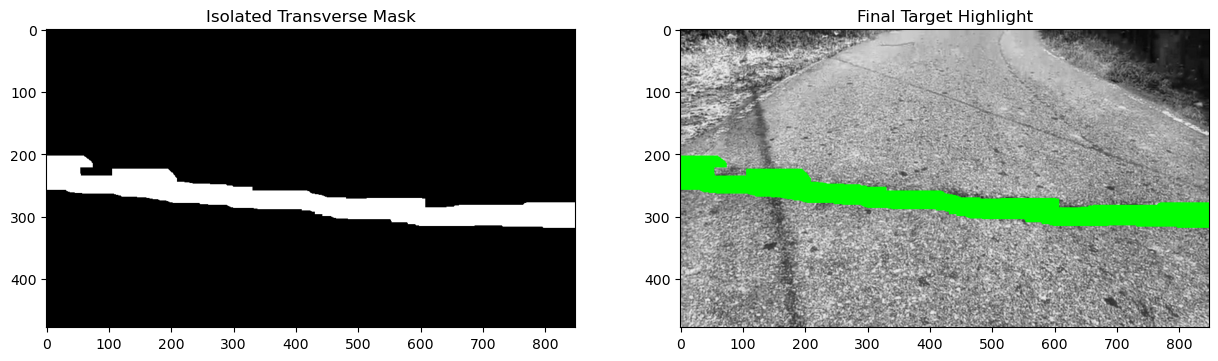

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def segment_precise_transverse(image):
    denoised = cv2.medianBlur(image, 11)

    edges = cv2.Canny(denoised, 80, 180)
    
    kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (45, 3))
    dilated = cv2.dilate(edges, kernel_h, iterations=2)

    closing_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 10))
    closed = cv2.morphologyEx(dilated, cv2.MORPH_CLOSE, closing_kernel)

    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(closed)
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 10000: 
            continue
            
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / float(h) if h > 0 else 0

        if aspect_ratio > 5.0:
            cv2.drawContours(mask, [cnt], -1, 255, -1)

    return mask

path = r"C:\Users\ASUS\OneDrive\Desktop\image processing project\transverse_cracking_enhanced\enhanced\enhanced_transverse_120.jpg"
img = cv2.imread(path, 0)

if img is not None:
    mask = segment_precise_transverse(img)

    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    overlay[mask > 0] = [0, 255, 0]

    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1); plt.imshow(mask, cmap='gray'); plt.title("Isolated Transverse Mask")
    plt.subplot(1, 2, 2); plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); plt.title("Final Target Highlight")
    plt.show()
else:
    print("Check file path.")

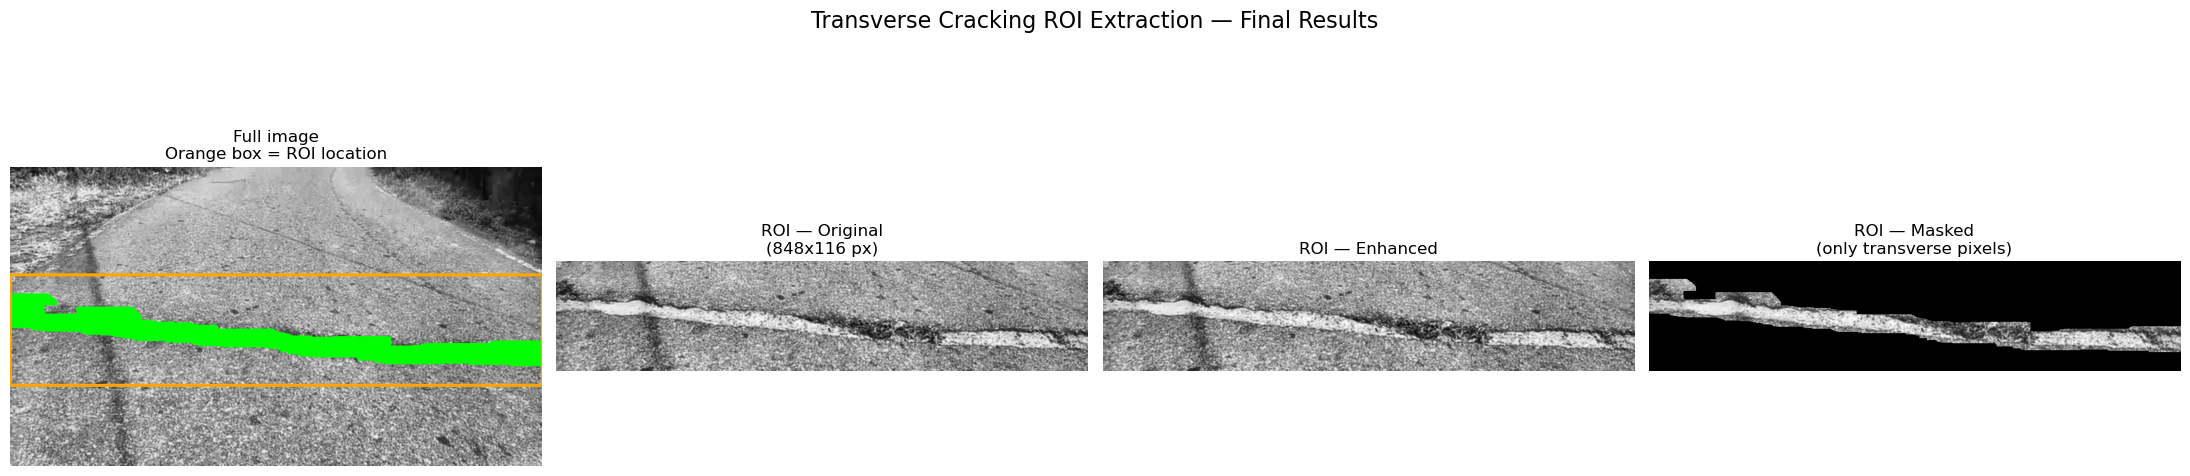


=== Transverse Extraction Info ===
Location: x=0, y=173
ROI Dimensions: 848 x 176 pixels
Affected Area: 31509 pixels


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)

    pad = 30
    x1, y1 = max(0, x - pad), max(0, y - pad)
    x2, y2 = min(img.shape[1], x + w + pad), min(img.shape[0], y + h + pad)

    roi_original = img[y1:y2, x1:x2]
    roi_enhanced = enhanced_img[y1:y2, x1:x2] 
    roi_mask     = mask[y1:y2, x1:x2]

    roi_masked = cv2.bitwise_and(roi_enhanced, roi_enhanced, mask=roi_mask)

    full_view_overlay = cv2.cvtColor(enhanced_img, cv2.COLOR_GRAY2BGR)
    full_view_overlay[mask > 0] = [0, 255, 0] 
    cv2.rectangle(full_view_overlay, (x1, y1), (x2, y2), (0, 165, 255), 3)

    fig, axes = plt.subplots(1, 4, figsize=(22, 6))

    axes[0].imshow(cv2.cvtColor(full_view_overlay, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Full image\nOrange box = ROI location")
    axes[0].axis('off')

    axes[1].imshow(roi_original, cmap='gray')
    axes[1].set_title(f"ROI — Original\n({w}x{h} px)")
    axes[1].axis('off')

    axes[2].imshow(roi_enhanced, cmap='gray')
    axes[2].set_title("ROI — Enhanced")
    axes[2].axis('off')

    axes[3].imshow(roi_masked, cmap='gray')
    axes[3].set_title("ROI — Masked\n(only transverse pixels)")
    axes[3].axis('off')

    plt.suptitle("Transverse Cracking ROI Extraction — Final Results", fontsize=16)
    plt.tight_layout()
    plt.show()

    print(f"\n=== Transverse Extraction Info ===")
    print(f"Location: x={x1}, y={y1}")
    print(f"ROI Dimensions: {x2-x1} x {y2-y1} pixels")
    print(f"Affected Area: {np.sum(roi_mask==255)} pixels")

else:
    print("No transverse crack detected for ROI extraction.")

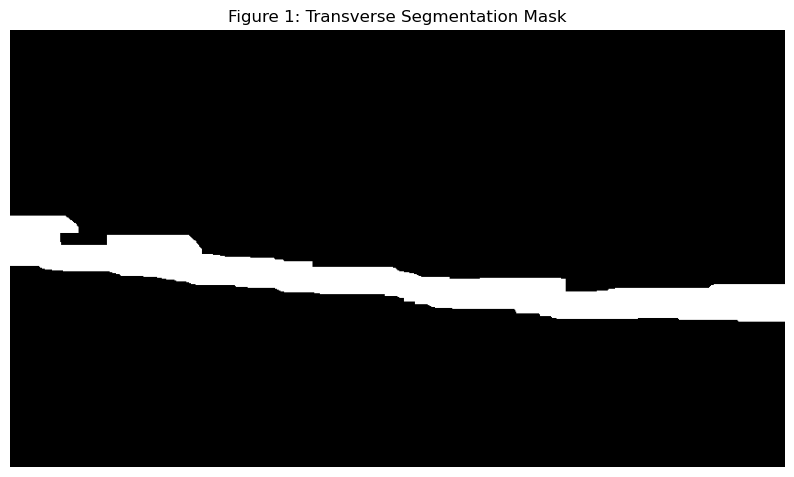

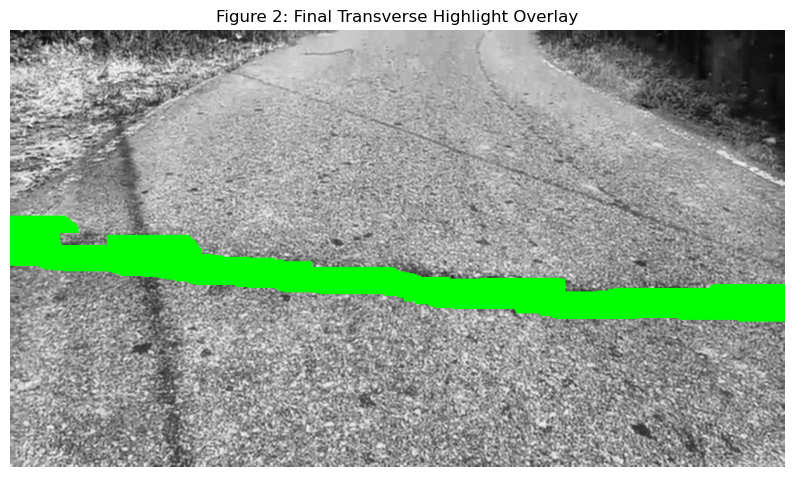

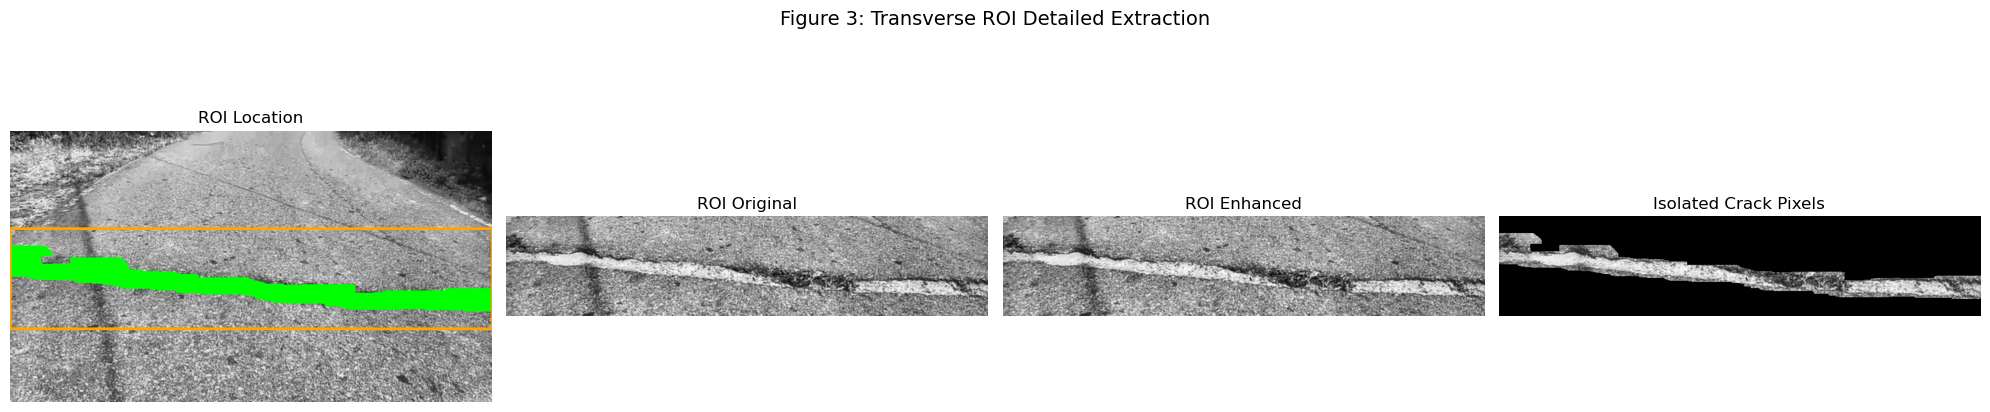

Crack Area: 31509 pixels


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))
plt.imshow(mask, cmap='gray')
plt.title("Figure 1: Transverse Segmentation Mask")
plt.axis('off')
plt.show()

overlay_full = cv2.cvtColor(enhanced_img, cv2.COLOR_GRAY2BGR)
overlay_full[mask > 0] = [0, 255, 0] 
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(overlay_full, cv2.COLOR_BGR2RGB))
plt.title("Figure 2: Final Transverse Highlight Overlay")
plt.axis('off')
plt.show()

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
 
    pad = 30
    x1, y1 = max(0, x - pad), max(0, y - pad)
    x2, y2 = min(img.shape[1], x + w + pad), min(img.shape[0], y + h + pad)

    roi_orig = img[y1:y2, x1:x2]
    roi_enh = enhanced_img[y1:y2, x1:x2]
    roi_m = mask[y1:y2, x1:x2]
    roi_masked = cv2.bitwise_and(roi_enh, roi_enh, mask=roi_m)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    roi_box_view = overlay_full.copy()
    cv2.rectangle(roi_box_view, (x1, y1), (x2, y2), (0, 165, 255), 3)
    axes[0].imshow(cv2.cvtColor(roi_box_view, cv2.COLOR_BGR2RGB))
    axes[0].set_title("ROI Location")
    
    # Comparison Panels
    axes[1].imshow(roi_orig, cmap='gray')
    axes[1].set_title("ROI Original")
    
    axes[2].imshow(roi_enh, cmap='gray')
    axes[2].set_title("ROI Enhanced")
    
    axes[3].imshow(roi_masked, cmap='gray')
    axes[3].set_title("Isolated Crack Pixels")

    for ax in axes:
        ax.axis('off')
    
    plt.suptitle("Figure 3: Transverse ROI Detailed Extraction", fontsize=14)
    plt.tight_layout()
    plt.show()

    print(f"Crack Area: {np.sum(roi_m==255)} pixels")
else:
    print("No crack detected for ROI extraction.")